In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from sklearn.preprocessing import RobustScaler

from tabulate import tabulate
import pymysql

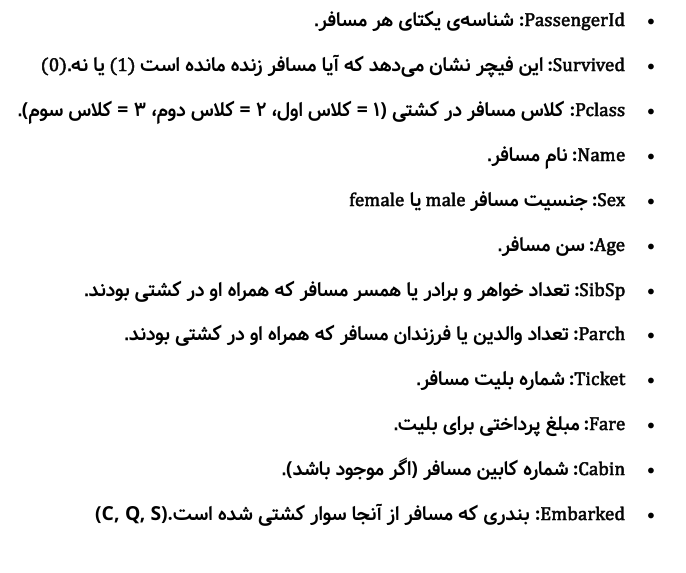

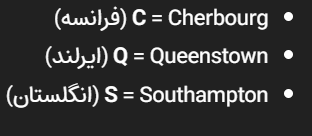

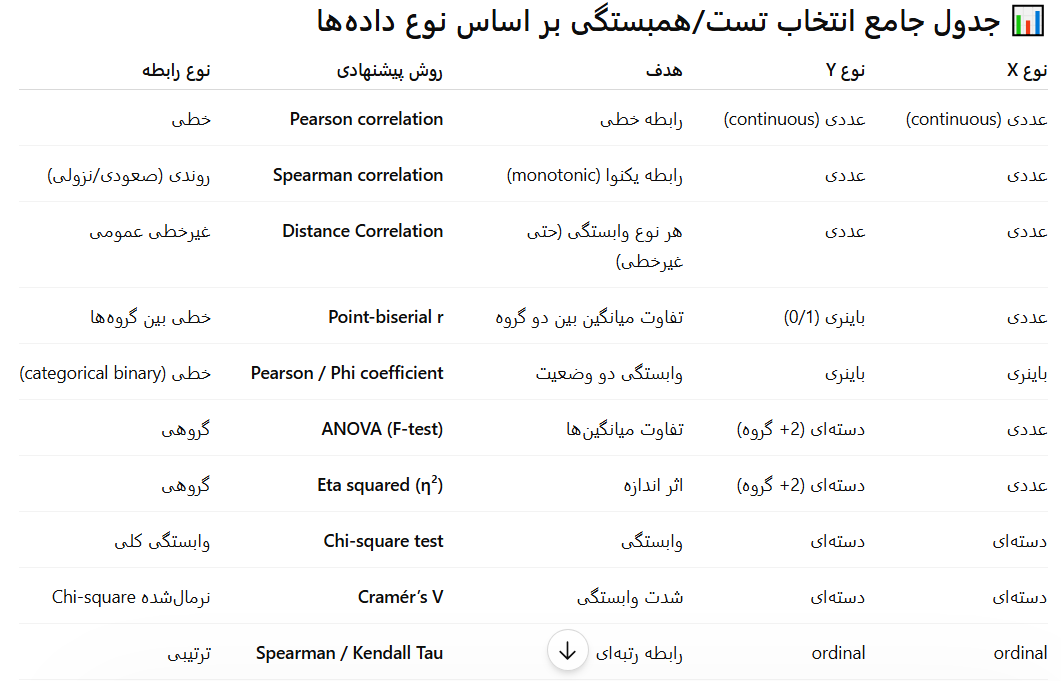

In [2]:
# conn = pymysql.connect(
#     host="localhost",
#     user="root",
#     password="hadi1502",
#     database="sql_store"
# )

In [3]:
# query_ = "SELECT * FROM titanic"

# df = pd.read_sql(query_, conn)
# df.head()

In [4]:
df = pd.read_csv(r'D:\data sets\titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print(df.columns)
df.set_index('PassengerId', inplace=True)
df 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [7]:
for column in df.select_dtypes('object'):
    uniq_value = df[column].unique()
    nuniq_value = df[column].nunique()
    print(f'مقادیر یونیک در ستون {column}: {uniq_value}')
    print(f'{column}: {nuniq_value}')
    print('*' * 50)

مقادیر یونیک در ستون Name: ['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima' 'Fynney, Mr. Joseph J' 'Beesley, Mr. Lawrence'
 'McGowan, Miss. Anna "Annie"' 'Sloper, Mr. William Thompson'
 'Palsson, Miss. Torborg Danira'
 'Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)'
 'Emir, Mr. Farred Chehab' 'Fortune, Mr. Charles Alexander'
 'O\'Dwyer, Mi

In [8]:
df.drop(["Name","Cabin"],axis=1,inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
2,1,1,female,38.0,1,0,PC 17599,71.2833,C
3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,1,1,female,35.0,1,0,113803,53.1000,S
5,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,211536,13.0000,S
888,1,1,female,19.0,0,0,112053,30.0000,S
889,0,3,female,NaN,1,2,W./C. 6607,23.4500,S


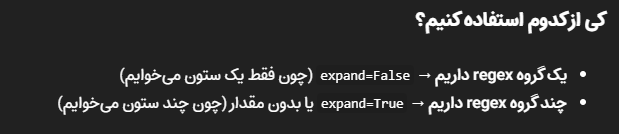

In [9]:
df['Ticket_Prefix'] = df['Ticket'].str.extract('([A-Za-z./]+)', expand=False)
df['Ticket_Prefix'] = df['Ticket_Prefix'].fillna('None')

"""
  ولی اگه ستون تیکت  خودش از قبل نن داشته باشه اون نن  اصلی هم به"non"  تبدیل می‌شه
 df.loc[df['Ticket'].notna() & df['Ticket_Prefix'].isna(), 'Ticket_Prefix'] = 'None'
"""
print(df['Ticket_Prefix'].value_counts())  

Ticket_Prefix
None          661
PC             60
C.A.           27
A/             23
STON/O         18
W./C.           9
CA.             8
SOTON/O.Q.      8
SOTON/OQ        7
CA              6
C               5
F.C.C.          5
SC/PARIS        5
S.O.C.          5
SC/Paris        4
LINE            4
S.O./P.P.       3
PP              3
SC/AH           3
S.C./PARIS      2
P/PP            2
SOTON/O         2
A./             2
A.              2
WE/P            2
S.W./PP         1
F.C.            1
A/S             1
SC              1
S.O.P.          1
SCO/W           1
SW/PP           1
W/C             1
Fa              1
A               1
W.E.P.          1
SO/C            1
S.P.            1
S.C./A.         1
C.A./SOTON      1
Name: count, dtype: int64


In [10]:
df.drop(['Ticket', 'Ticket_Prefix'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S
888,1,1,female,19.0,0,0,30.0000,S
889,0,3,female,NaN,1,2,23.4500,S


In [11]:
for column in df.select_dtypes(include='number'):
    nuniq = df[column].nunique()
    print(f'\nستون: {column}')
  
    if nuniq < 20:
        print(f'نوع: گسسته (Discrete)')
        print(df[column].value_counts().sort_index())
    else:
        print(f'نوع: پیوسته (Continuous)')
        print(f'تعداد مقادیر یونیک: {nuniq}')
        print(f'Min: {df[column].min()}, Max: {df[column].max()}')
        print(f'Mean: {df[column].mean():.2f}, Median: {df[column].median():.2f}')
    
    print(f'تعداد NaN: {df[column].isnull().sum()}')
    print('*' * 50) 


ستون: Survived
نوع: گسسته (Discrete)
Survived
0    549
1    342
Name: count, dtype: int64
تعداد NaN: 0
**************************************************

ستون: Pclass
نوع: گسسته (Discrete)
Pclass
1    216
2    184
3    491
Name: count, dtype: int64
تعداد NaN: 0
**************************************************

ستون: Age
نوع: پیوسته (Continuous)
تعداد مقادیر یونیک: 88
Min: 0.42, Max: 80.0
Mean: 29.70, Median: 28.00
تعداد NaN: 177
**************************************************

ستون: SibSp
نوع: گسسته (Discrete)
SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64
تعداد NaN: 0
**************************************************

ستون: Parch
نوع: گسسته (Discrete)
Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64
تعداد NaN: 0
**************************************************

ستون: Fare
نوع: پیوسته (Continuous)
تعداد مقادیر یونیک: 248
Min: 0.0, Max: 512.3292
Mean: 32.20, Median: 14.45
تعداد NaN: 0

In [12]:
print(df.isna().sum())
print(df.isna().sum(axis=1).sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
179


In [13]:
print(df.groupby('Pclass')['Age'].median()) 
print(df.groupby('Embarked')['Age'].median()) 

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64
Embarked
C    29.0
Q    27.0
S    28.0
Name: Age, dtype: float64


In [14]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S
888,1,1,female,19.0,0,0,30.0000,S
889,0,3,female,NaN,1,2,23.4500,S


In [15]:
# df[['Sex', 'Embarked']] = df[['Sex', 'Embarked']].astype('category')
df[['Survived', 'Pclass', "SibSp", "Parch"]] = df[['Survived', 'Pclass', "SibSp", "Parch"]].astype('float')
df.dtypes  


Survived    float64
Pclass      float64
Sex          object
Age         float64
SibSp       float64
Parch       float64
Fare        float64
Embarked     object
dtype: object

<Figure size 1000x600 with 0 Axes>

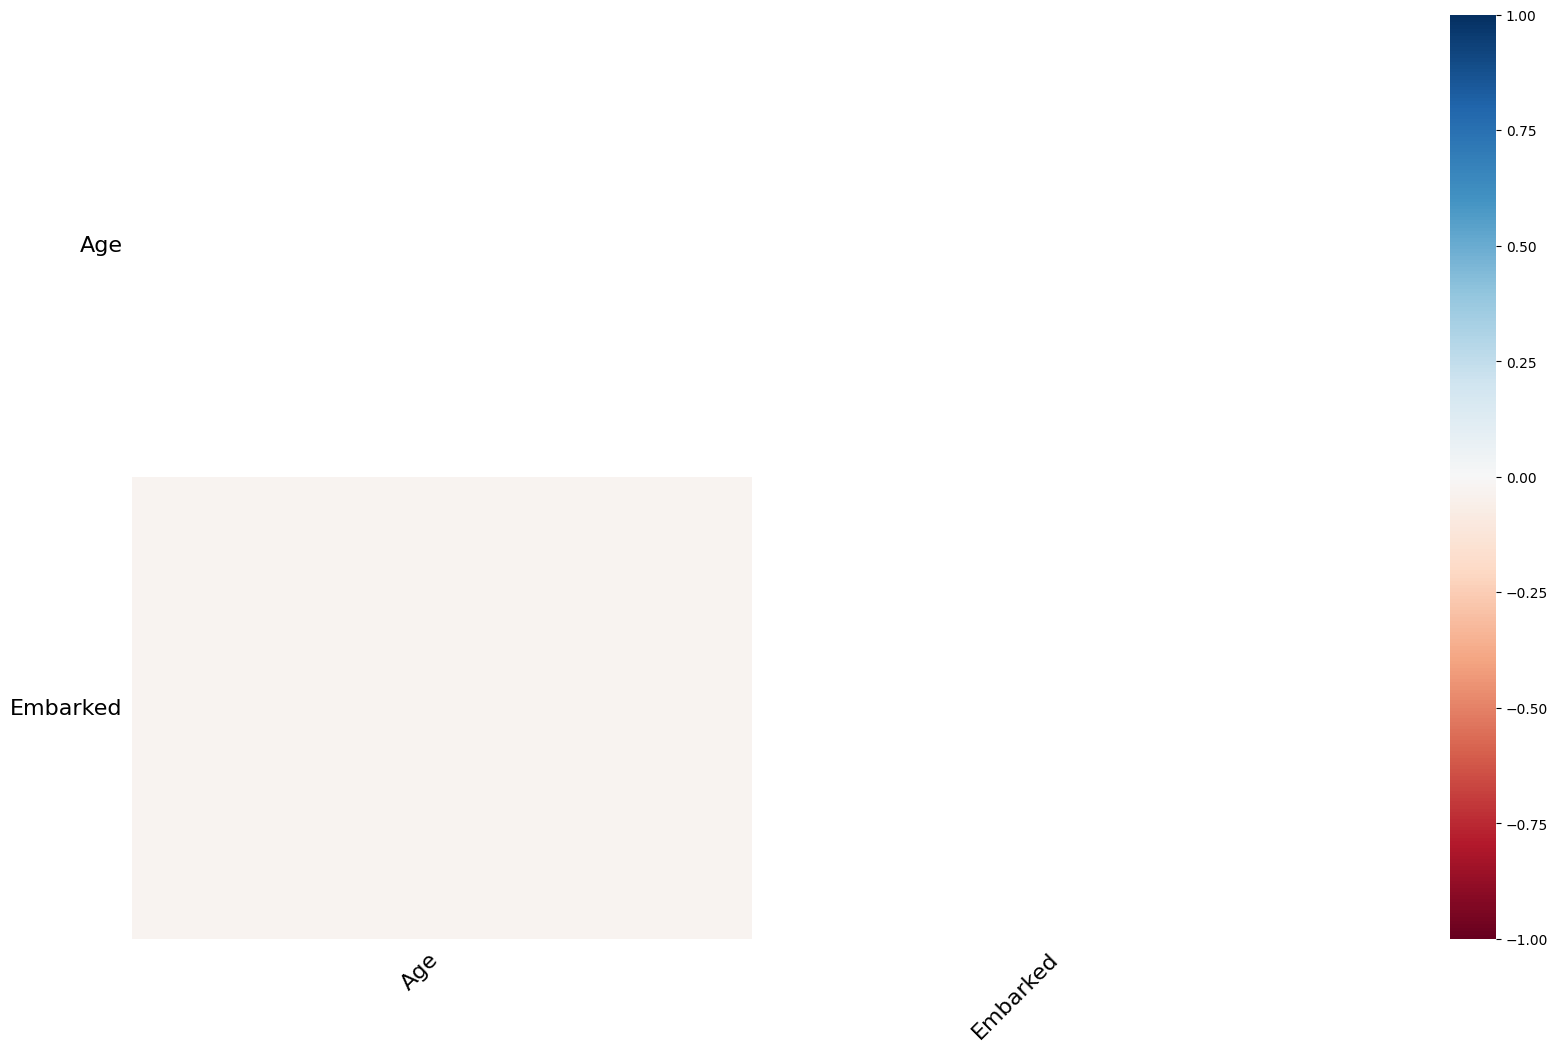

In [16]:
plt.figure(figsize=(10,6))
msno.heatmap(df,labels=True)
plt.show()

In [17]:
def diagnose_mv(df, mv_column):
    cols = list(df.columns)
    cols.remove(mv_column)

    flags = df[mv_column].isna()

    fig, ax = plt.subplots(len(cols), 3,
                           figsize=(15, 4*len(cols)),
                           constrained_layout=True)

    plt.rcParams['axes.grid'] = True

    for i, col in enumerate(cols):

        if pd.api.types.is_numeric_dtype(df[col]):

            n1, bins, _ = ax[i,0].hist(df[col].dropna())
            ax[i,0].set_title(f'{col} with MV')

            n2, _, _ = ax[i,1].hist(df.loc[~flags, col].dropna(), bins=bins)
            ax[i,1].set_title(f'{col} without MV')

            ax[i,2].bar(bins[:-1], np.abs(n2-n1), width=np.abs(bins[1]-bins[0]))
            ax[i,2].set_title('Difference')

        else:

            vc1 = df[col].value_counts()
            vc2 = df.loc[~flags, col].value_counts() 

            cats = sorted(set(vc1.index) | set(vc2.index))
            v1 = [vc1.get(c, 0) for c in cats]
            v2 = [vc2.get(c, 0) for c in cats]

            ax[i,0].bar(cats, v1)
            ax[i,0].set_title(f'{col} with MV')

            ax[i,1].bar(cats, v2)
            ax[i,1].set_title(f'{col} without MV')

            diff = np.abs(np.array(v1) - np.array(v2))
            ax[i,2].bar(cats, diff)
            ax[i,2].set_title('Difference')



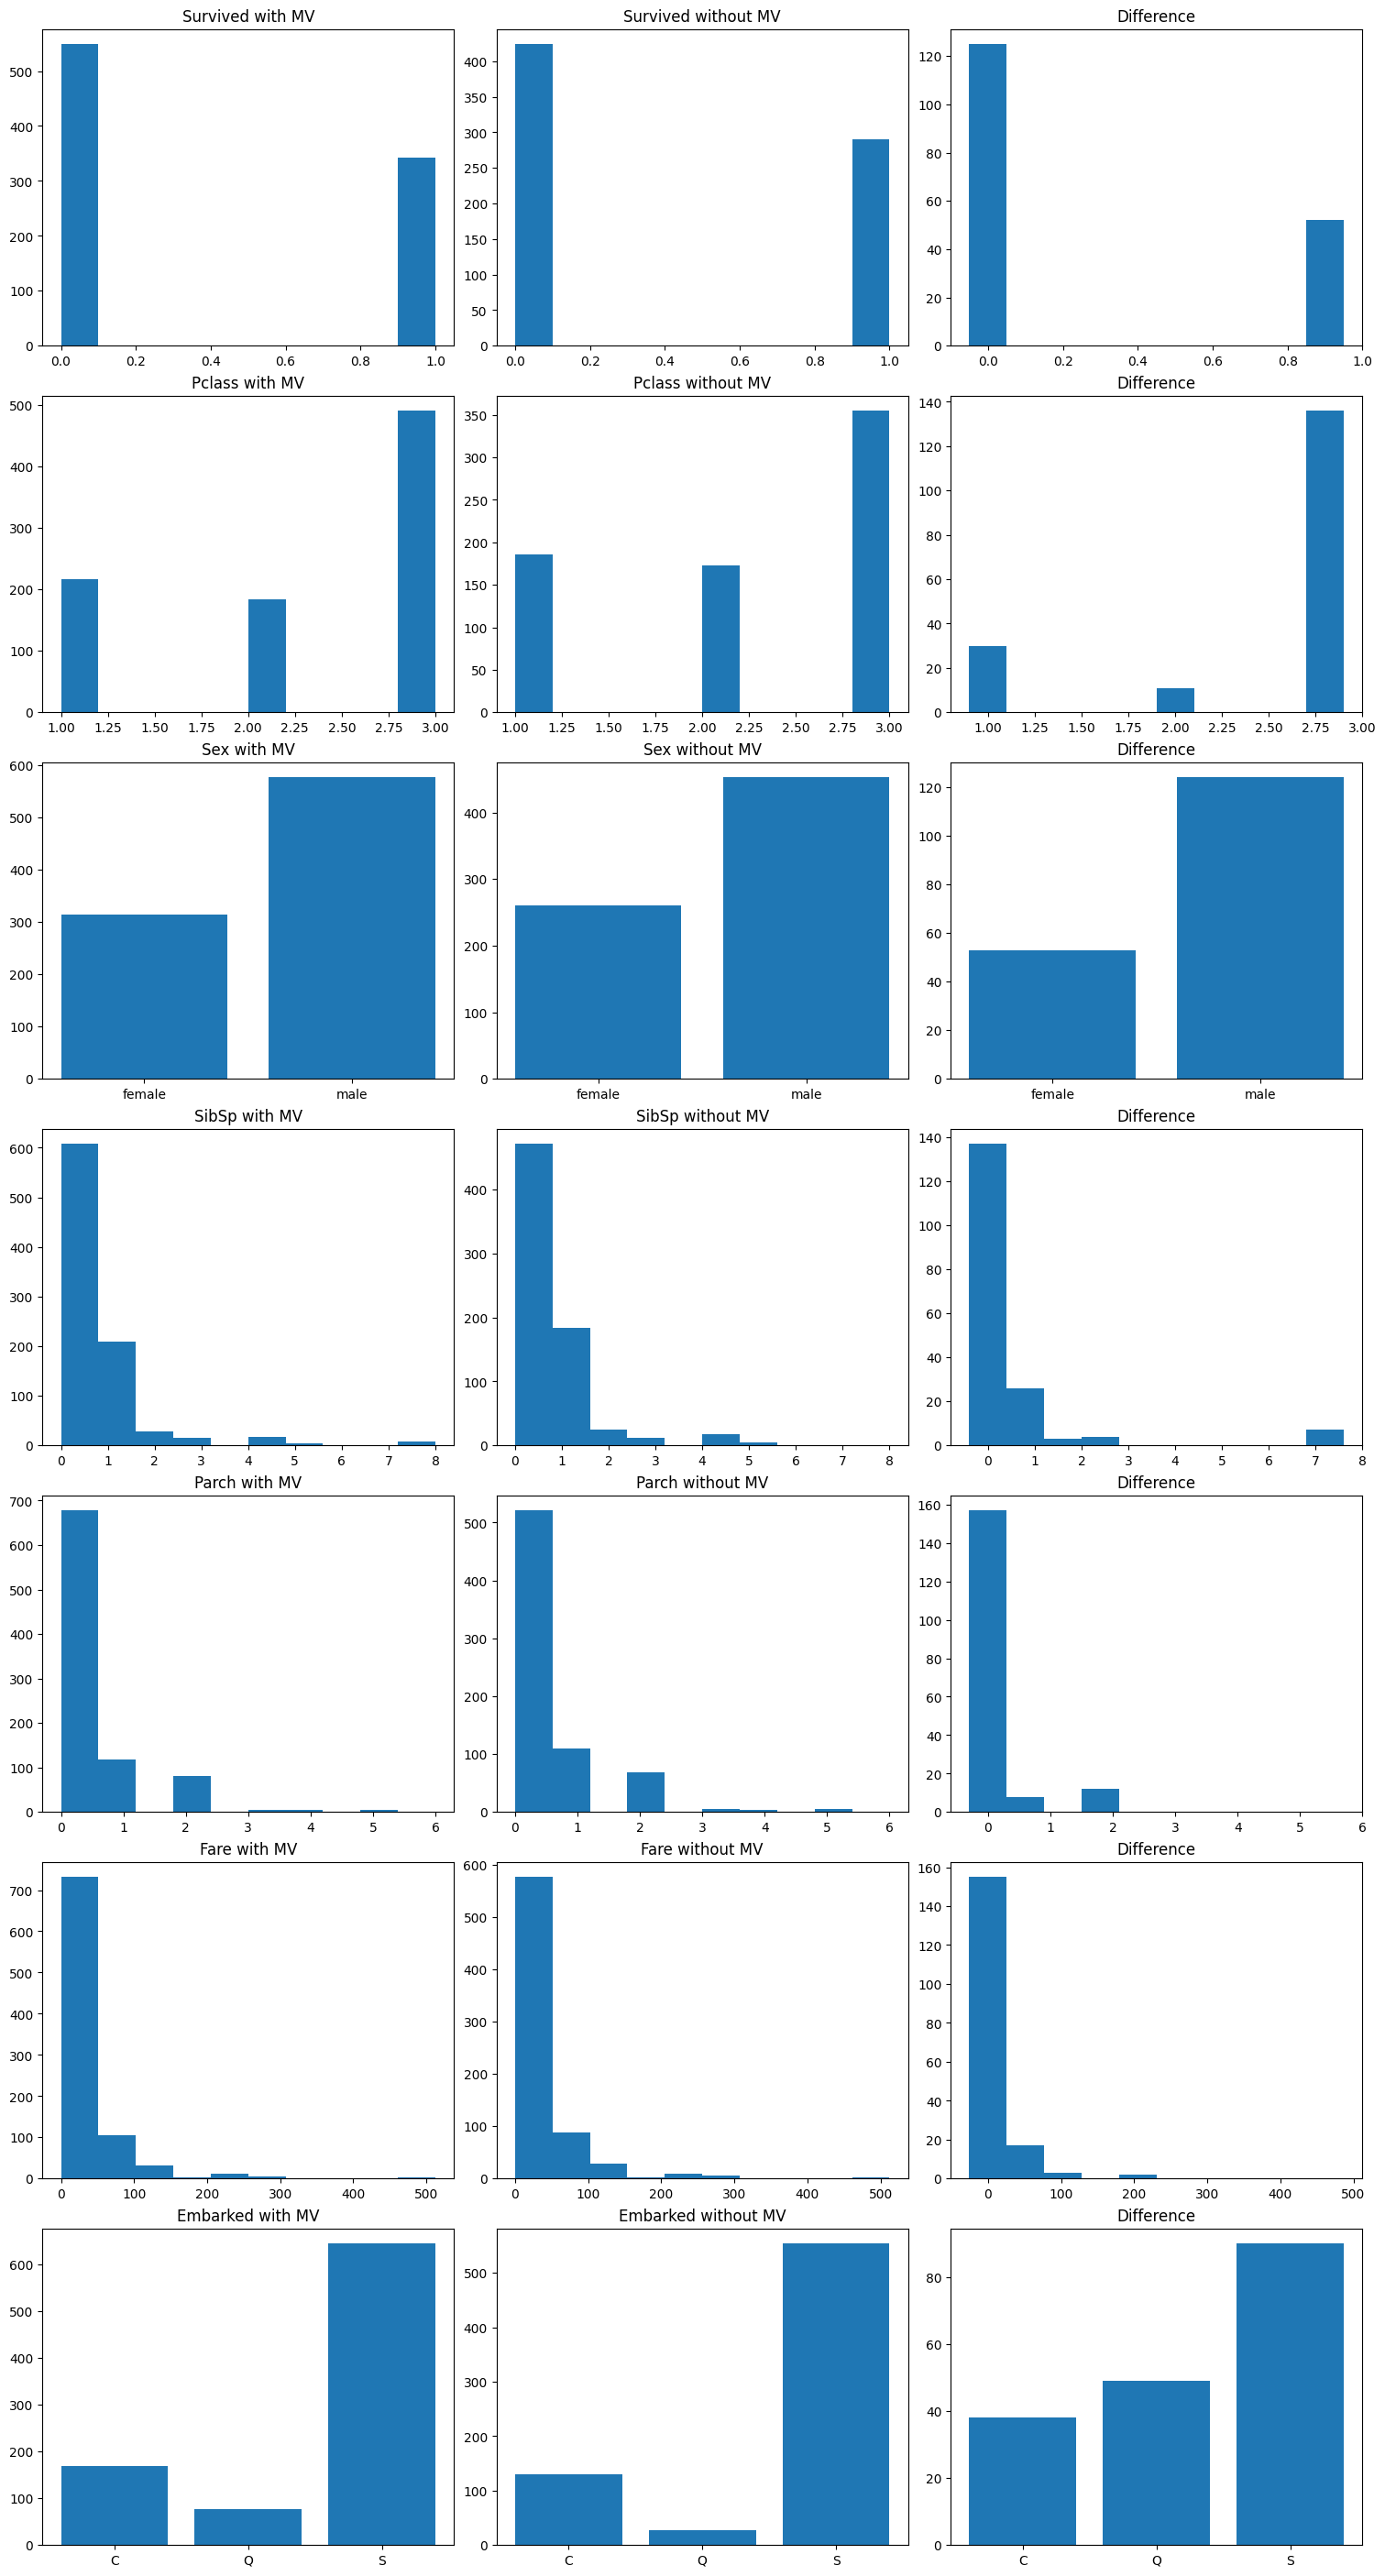

In [ ]:
diagnose_mv(df, "Age")

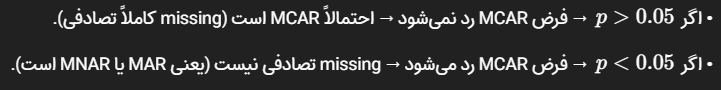

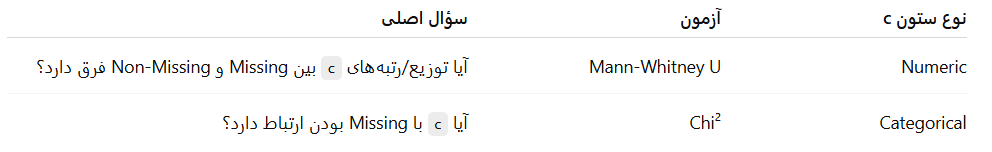

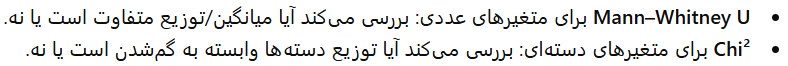

https://en.wikipedia.org/wiki/Bonferroni_correction

In [19]:
import warnings
warnings.filterwarnings("ignore")
# ─────────────────────────────────────────────
# Helper 1: MCAR test
# ─────────────────────────────────────────────
# ==========================================================
# MCAR TEST
# ==========================================================
def _mcar_test(df, col, alpha=0.05):

    missing_mask = df[col].isna()

    if missing_mask.sum() < 5:
        return None, None

    if (~missing_mask).sum() < 5:
        return None, None

    p_values = []

    for c in df.columns:

        if c == col:
            continue

        grp_miss = df.loc[missing_mask, c].dropna()
        grp_non = df.loc[~missing_mask, c].dropna()

        if len(grp_miss) < 5 or len(grp_non) < 5:
            continue

        try:

            if pd.api.types.is_numeric_dtype(df[c]):

                _, p = stats.mannwhitneyu(
                    grp_miss,
                    grp_non,
                    alternative="two-sided"
                )

            else:
                #  پر کردن بامیسینگ تضمین می‌کند که همه‌ی داده‌ها (حتی گمشده‌ها) در بررسی وابستگی دخیل باشند و ام کار به‌درستی ارزیابی شود.
                ct = pd.crosstab(
                    df[c].fillna("Missing"),
                    missing_mask
                )

                if ct.shape[0] < 2:
                    continue

                _, p, _, _ = stats.chi2_contingency(ct)

            p_values.append(p)

        except Exception:
            continue

    if len(p_values) == 0:
        return None, None

    alpha_corrected = alpha / len(p_values)

    is_mcar = all(
        p > alpha_corrected
        for p in p_values
    )

    return is_mcar, min(p_values)



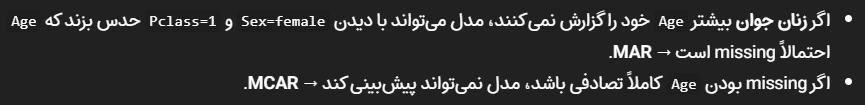

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
 
# ==========================================================
# MAR TEST
# ==========================================================
def _mar_test(df, col):

    missing_mask = df[col].isna().astype(int)

    if missing_mask.sum() < 10:
        return None, None

    if (1 - missing_mask).sum() < 10:
        return None, None

    X = df.drop(columns=[col]).copy()

    cat_cols = X.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    if len(cat_cols):

        X = pd.get_dummies(
            X,
            columns=cat_cols,
            drop_first=True,
            dtype=int
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        missing_mask,
        test_size=0.30,
        random_state=42,
        stratify=missing_mask
    )

    medians = X_train.median()

    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)

    try:

        model = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train, y_train)

        prob = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(
            y_test,
            prob
        )

        mar_evidence = auc >= 0.70

        return mar_evidence, auc

    except Exception:

        return None, None

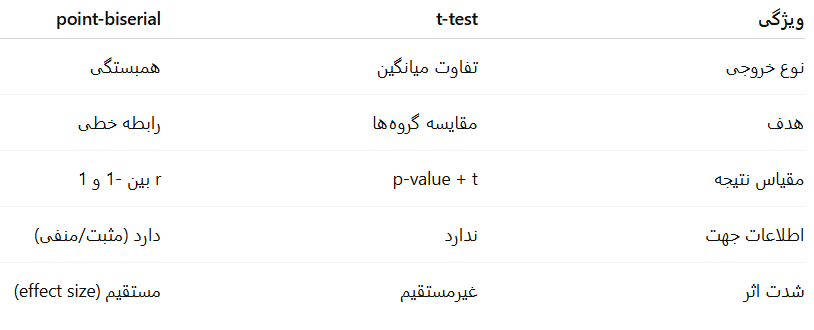

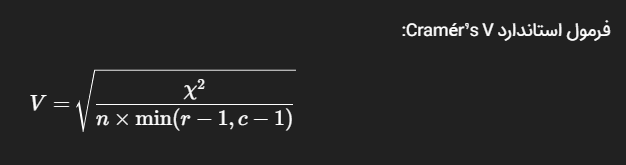

In [21]:
# ==========================================================
# RELATED COLUMNS
# ==========================================================
def _mar_column_importance(df, col, top_n=5):

    missing_mask = df[col].isna().astype(int)  

    scores = {}

    for c in df.columns:

        if c == col:
            continue

        try:

            series = df[c]

            # ======================================================
            # NUMERIC / BINARY
            # ======================================================
            if pd.api.types.is_numeric_dtype(series):

                valid = series.dropna()
                y = missing_mask.loc[valid.index]

                if len(valid) < 5:
                    continue

                # -----------------------------
                # CASE 1: binary-binary → Pearson (phi)
                # -----------------------------
                if set(valid.unique()).issubset({0, 1}):

                    if y.nunique() < 2:
                        continue

                    corr = y.corr(valid)

                # -----------------------------
                # CASE 2: numeric-binary → point biserial
                # -----------------------------
                else:

                    if y.nunique() < 2:
                        continue

                    corr, _ = stats.pointbiserialr(y, valid)

                if np.isnan(corr):
                    continue

                scores[c] = abs(corr)

            # ======================================================
            # CATEGORICAL
            # ======================================================
            else:

                ct = pd.crosstab(
                    series.fillna("Missing"),
                    missing_mask
                )

                if ct.shape[0] < 2 or ct.shape[1] < 2:
                    continue

                chi2, _, _, _ = stats.chi2_contingency(ct)

                n = ct.values.sum()
                if n == 0:
                    continue

                r, k = ct.shape

                phi2 = chi2 / n

                phi2corr = max(
                    0,
                    phi2 - ((k - 1) * (r - 1)) / (n - 1)
                )

                rcorr = r - ((r - 1) ** 2) / (n - 1)
                kcorr = k - ((k - 1) ** 2) / (n - 1)

                denom = min(kcorr - 1, rcorr - 1)

                if denom <= 0:
                    continue

                cramers_v = np.sqrt(phi2corr / denom)

                scores[c] = cramers_v

        except Exception:
            continue

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

In [22]:
# ==========================================================
# MAIN
# ==========================================================
def diagnose_mv(df, columns=None):

    if columns is None:
        columns = [
            c
            for c in df.columns
            if df[c].isna().any()
        ]

    if not columns:

        print("No missing values found.")
        return {}

    results = {}

    for col in columns:

        miss_rate = df[col].isna().mean()

        print("\n" + "=" * 60)
        print(
            f"Column: {col} | Missing Rate: {miss_rate:.1%}"
        )

        if miss_rate < 0.01:
            print(
                "⚠ Very low missing rate (<1%)."
            )

        elif miss_rate > 0.60:
            print(
                "⚠ Very high missing rate (>60%)."
            )

        is_mcar, mcar_p = _mcar_test(df, col)

        mar_evidence, mar_auc = _mar_test(df, col)

        if is_mcar is True:

            mv_type = "MCAR plausible"

        elif mar_evidence is True:

            mv_type = "MAR evidence"

        else:

            mv_type = "Undetermined"

        top_related = []

        if mar_evidence:

            top_related = _mar_column_importance(
                df,
                col
            )

        print(
            f"MCAR p-value : "
            f"{mcar_p:.4f}"
            if mcar_p is not None
            else "MCAR p-value : N/A"
        )

        print(
            f"MAR AUC      : "
            f"{mar_auc:.3f}"
            if mar_auc is not None
            else "MAR AUC      : N/A"
        )

        print(
            f"Type         : {mv_type}"
        )

        if top_related:

            print(
                "Top related  :",
                [
                    f"{c} ({s:.2f})"
                    for c, s in top_related
                ]
            )

        results[col] = {
            "type": mv_type,
            "miss_rate": miss_rate,
            "mcar_p": mcar_p,
            "mar_auc": mar_auc,
            "top_related": top_related
        }

    return results 

In [23]:
results = diagnose_mv(df, columns=['Age'])
results


Column: Age | Missing Rate: 19.9%
MCAR p-value : 0.0000
MAR AUC      : 0.749
Type         : MAR evidence
Top related  : ['Embarked (0.34)', 'Pclass (0.17)', 'Parch (0.12)', 'Fare (0.10)', 'Survived (0.09)']


{'Age': {'type': 'MAR evidence',
  'miss_rate': 0.19865319865319866,
  'mcar_p': 2.951041813028417e-23,
  'mar_auc': 0.7492321193505924,
  'top_related': [('Embarked', 0.3434789091090832),
   ('Pclass', 0.17293285906128972),
   ('Parch', 0.124103825509146),
   ('Fare', 0.1007070978779614),
   ('Survived', 0.09219652324217216)]}}

In [24]:
df.groupby(['Embarked', 'Pclass', 'Parch'])['Age'].median() 

Embarked  Pclass  Parch
C         1.0     0.0      36.0
                  1.0      40.0
                  2.0      21.5
          2.0     0.0      27.5
                  1.0      31.0
                  2.0      12.5
          3.0     0.0      25.0
                  1.0       9.0
                  2.0      15.0
                  3.0      24.0
Q         1.0     0.0      38.5
          2.0     0.0      43.5
          3.0     0.0      22.0
                  1.0       7.5
                  2.0       NaN
                  5.0      39.0
S         1.0     0.0      39.0
                  1.0      43.0
                  2.0      19.0
                  4.0      64.0
          2.0     0.0      31.0
                  1.0      23.0
                  2.0      24.0
                  3.0      39.0
          3.0     0.0      26.0
                  1.0      16.0
                  2.0       9.0
                  3.0      32.0
                  4.0      40.0
                  5.0      39.0
                

In [ ]:
# مرحله 1
df['Age'] = ( 
    df.groupby(['Embarked', 'Pclass', 'Parch'])['Age']
      .transform(lambda x: x.fillna(x.median()))
)

# مرحله 2
df['Age'] = (
    df.groupby('Pclass')['Age']
      .transform(lambda x: x.fillna(x.median()))  
)

# مرحله 3
df['Age'] = df['Age'].fillna(df['Age'].median())

In [26]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [27]:
df.dropna(subset="Embarked",inplace=True)
df 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0.0,3.0,male,22.0,1.0,0.0,7.2500,S
2,1.0,1.0,female,38.0,1.0,0.0,71.2833,C
3,1.0,3.0,female,26.0,0.0,0.0,7.9250,S
4,1.0,1.0,female,35.0,1.0,0.0,53.1000,S
5,0.0,3.0,male,35.0,0.0,0.0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0.0,2.0,male,27.0,0.0,0.0,13.0000,S
888,1.0,1.0,female,19.0,0.0,0.0,30.0000,S
889,0.0,3.0,female,9.0,1.0,2.0,23.4500,S


In [28]:
df = df.reset_index(drop=True)
df 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3.0,male,22.0,1.0,0.0,7.2500,S
1,1.0,1.0,female,38.0,1.0,0.0,71.2833,C
2,1.0,3.0,female,26.0,0.0,0.0,7.9250,S
3,1.0,1.0,female,35.0,1.0,0.0,53.1000,S
4,0.0,3.0,male,35.0,0.0,0.0,8.0500,S
...,...,...,...,...,...,...,...,...
884,0.0,2.0,male,27.0,0.0,0.0,13.0000,S
885,1.0,1.0,female,19.0,0.0,0.0,30.0000,S
886,0.0,3.0,female,9.0,1.0,2.0,23.4500,S
887,1.0,1.0,male,26.0,0.0,0.0,30.0000,C


In [29]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0.0,3.0,male,22.0,1.0,0.0,7.2500,S,2.0
1,1.0,1.0,female,38.0,1.0,0.0,71.2833,C,2.0
2,1.0,3.0,female,26.0,0.0,0.0,7.9250,S,1.0
3,1.0,1.0,female,35.0,1.0,0.0,53.1000,S,2.0
4,0.0,3.0,male,35.0,0.0,0.0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
884,0.0,2.0,male,27.0,0.0,0.0,13.0000,S,1.0
885,1.0,1.0,female,19.0,0.0,0.0,30.0000,S,1.0
886,0.0,3.0,female,9.0,1.0,2.0,23.4500,S,4.0
887,1.0,1.0,male,26.0,0.0,0.0,30.0000,C,1.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    float64
 1   Pclass      889 non-null    float64
 2   Sex         889 non-null    object 
 3   Age         889 non-null    float64
 4   SibSp       889 non-null    float64
 5   Parch       889 non-null    float64
 6   Fare        889 non-null    float64
 7   Embarked    889 non-null    object 
 8   FamilySize  889 non-null    float64
dtypes: float64(7), object(2)
memory usage: 62.6+ KB


In [31]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
label_encoder = LabelEncoder()
dfe = df.copy()

dfe["Sex"] = label_encoder.fit_transform(dfe["Sex"])
dfe

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0.0,3.0,1,22.0,1.0,0.0,7.2500,S,2.0
1,1.0,1.0,0,38.0,1.0,0.0,71.2833,C,2.0
2,1.0,3.0,0,26.0,0.0,0.0,7.9250,S,1.0
3,1.0,1.0,0,35.0,1.0,0.0,53.1000,S,2.0
4,0.0,3.0,1,35.0,0.0,0.0,8.0500,S,1.0
...,...,...,...,...,...,...,...,...,...
884,0.0,2.0,1,27.0,0.0,0.0,13.0000,S,1.0
885,1.0,1.0,0,19.0,0.0,0.0,30.0000,S,1.0
886,0.0,3.0,0,9.0,1.0,2.0,23.4500,S,4.0
887,1.0,1.0,1,26.0,0.0,0.0,30.0000,C,1.0


In [32]:
onehot_encoder= OneHotEncoder(sparse_output=False)
onehot_encoder_data= onehot_encoder.fit_transform(dfe[['Embarked']])
onehot_encoder_data

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [33]:
onehot_encoder_df= pd.DataFrame(onehot_encoder_data, columns=onehot_encoder.get_feature_names_out(['Embarked']))
onehot_encoder_df

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
884,0.0,0.0,1.0
885,0.0,0.0,1.0
886,0.0,0.0,1.0
887,1.0,0.0,0.0


In [34]:
dfe = pd.concat([dfe, onehot_encoder_df], axis=1)
dfe = dfe.drop(['Embarked'],axis=1)
dfe 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3.0,1,22.0,1.0,0.0,7.2500,2.0,0.0,0.0,1.0
1,1.0,1.0,0,38.0,1.0,0.0,71.2833,2.0,1.0,0.0,0.0
2,1.0,3.0,0,26.0,0.0,0.0,7.9250,1.0,0.0,0.0,1.0
3,1.0,1.0,0,35.0,1.0,0.0,53.1000,2.0,0.0,0.0,1.0
4,0.0,3.0,1,35.0,0.0,0.0,8.0500,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
884,0.0,2.0,1,27.0,0.0,0.0,13.0000,1.0,0.0,0.0,1.0
885,1.0,1.0,0,19.0,0.0,0.0,30.0000,1.0,0.0,0.0,1.0
886,0.0,3.0,0,9.0,1.0,2.0,23.4500,4.0,0.0,0.0,1.0
887,1.0,1.0,1,26.0,0.0,0.0,30.0000,1.0,1.0,0.0,0.0


In [35]:
dfe['Sex'] = dfe['Sex'].astype('float')

In [36]:
dfe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    float64
 1   Pclass      889 non-null    float64
 2   Sex         889 non-null    float64
 3   Age         889 non-null    float64
 4   SibSp       889 non-null    float64
 5   Parch       889 non-null    float64
 6   Fare        889 non-null    float64
 7   FamilySize  889 non-null    float64
 8   Embarked_C  889 non-null    float64
 9   Embarked_Q  889 non-null    float64
 10  Embarked_S  889 non-null    float64
dtypes: float64(11)
memory usage: 76.5 KB


In [37]:
dfe.columns
dfe= dfe[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q','FamilySize', 'Embarked_S','Survived']] 
dfe

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,FamilySize,Embarked_S,Survived
0,3.0,1.0,22.0,1.0,0.0,7.2500,0.0,0.0,2.0,1.0,0.0
1,1.0,0.0,38.0,1.0,0.0,71.2833,1.0,0.0,2.0,0.0,1.0
2,3.0,0.0,26.0,0.0,0.0,7.9250,0.0,0.0,1.0,1.0,1.0
3,1.0,0.0,35.0,1.0,0.0,53.1000,0.0,0.0,2.0,1.0,1.0
4,3.0,1.0,35.0,0.0,0.0,8.0500,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
884,2.0,1.0,27.0,0.0,0.0,13.0000,0.0,0.0,1.0,1.0,0.0
885,1.0,0.0,19.0,0.0,0.0,30.0000,0.0,0.0,1.0,1.0,1.0
886,3.0,0.0,9.0,1.0,2.0,23.4500,0.0,0.0,4.0,1.0,0.0
887,1.0,1.0,26.0,0.0,0.0,30.0000,1.0,0.0,1.0,0.0,1.0


[(0, 'Survived'), (1, 'Pclass'), (2, 'Sex'), (3, 'Age'), (4, 'SibSp'), (5, 'Parch'), (6, 'Fare'), (7, 'Embarked'), (8, 'FamilySize')]


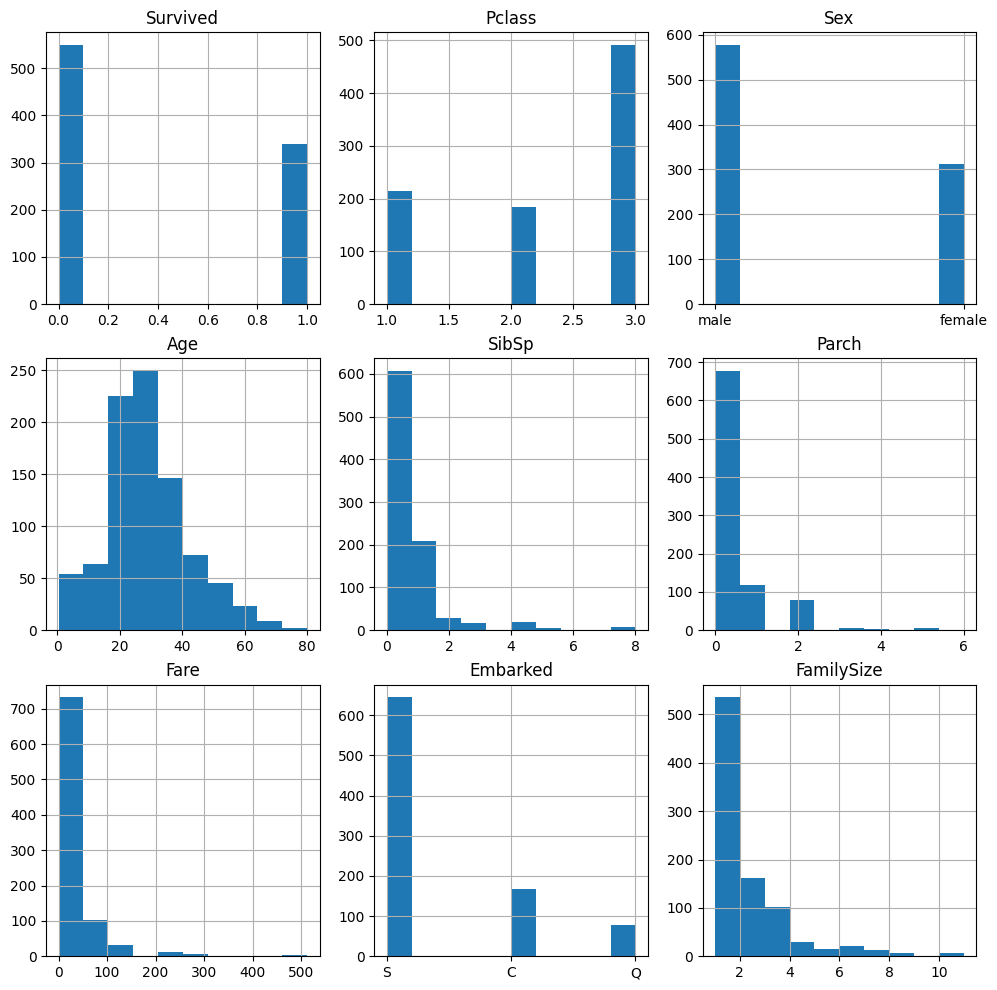

In [38]:
print(list(enumerate(df.columns)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes_flat = axes.flatten()


for i, col in enumerate(df.columns):
    ax = axes_flat[i]
    ax.hist(df[col])
    ax.set_title(col)

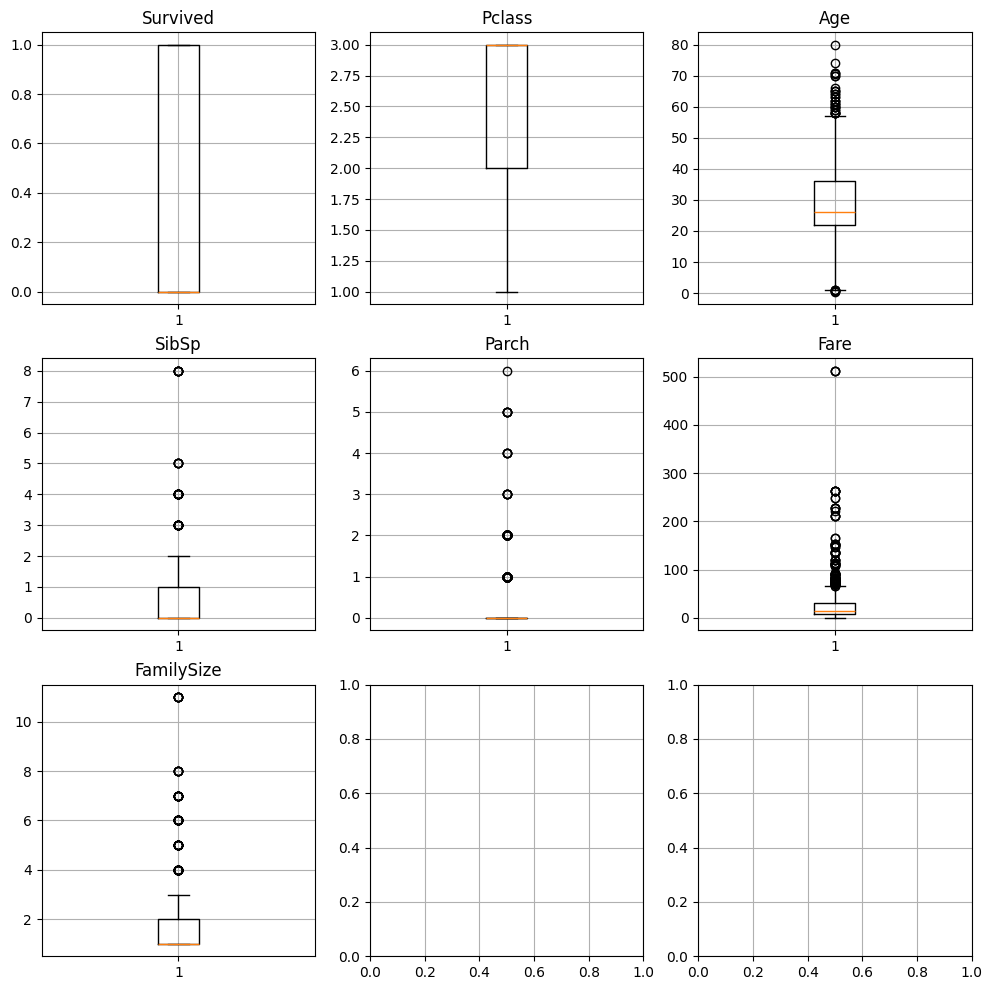

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes_flat = axes.flatten()

for i, col in enumerate(df.select_dtypes('float64')):
        ax = axes_flat[i]
        ax.boxplot(df[col])
        ax.set_title(col)

In [40]:
dfe.corr()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,FamilySize,Embarked_S,Survived
Pclass,1.000000,0.127741,-0.416381,0.081656,0.016824,-0.548193,-0.245733,0.220558,0.064221,0.076466,-0.335549
Sex,0.127741,1.000000,0.094694,-0.116348,-0.247508,-0.179958,-0.084520,-0.075217,-0.203191,0.121405,-0.541585
Age,-0.416381,0.094694,1.000000,-0.309228,-0.199912,0.112701,0.035429,-0.099043,-0.311251,0.031306,-0.050053
SibSp,0.081656,-0.116348,-0.309228,1.000000,0.414542,0.160887,-0.060074,-0.026692,0.890654,0.069438,-0.034040
Parch,0.016824,-0.247508,-0.199912,0.414542,1.000000,0.217532,-0.011588,-0.081585,0.782988,0.061512,0.083151
Fare,-0.548193,-0.179958,0.112701,0.160887,0.217532,1.000000,0.270731,-0.116684,0.218658,-0.163758,0.255290
Embarked_C,-0.245733,-0.084520,0.035429,-0.060074,-0.011588,0.270731,1.000000,-0.148646,-0.046852,-0.782613,0.169966
Embarked_Q,0.220558,-0.075217,-0.099043,-0.026692,-0.081585,-0.116684,-0.148646,1.000000,-0.059007,-0.499261,0.004536
FamilySize,0.064221,-0.203191,-0.311251,0.890654,0.782988,0.218658,-0.046852,-0.059007,1.000000,0.078197,0.018277
Embarked_S,0.076466,0.121405,0.031306,0.069438,0.061512,-0.163758,-0.782613,-0.499261,0.078197,1.000000,-0.151777


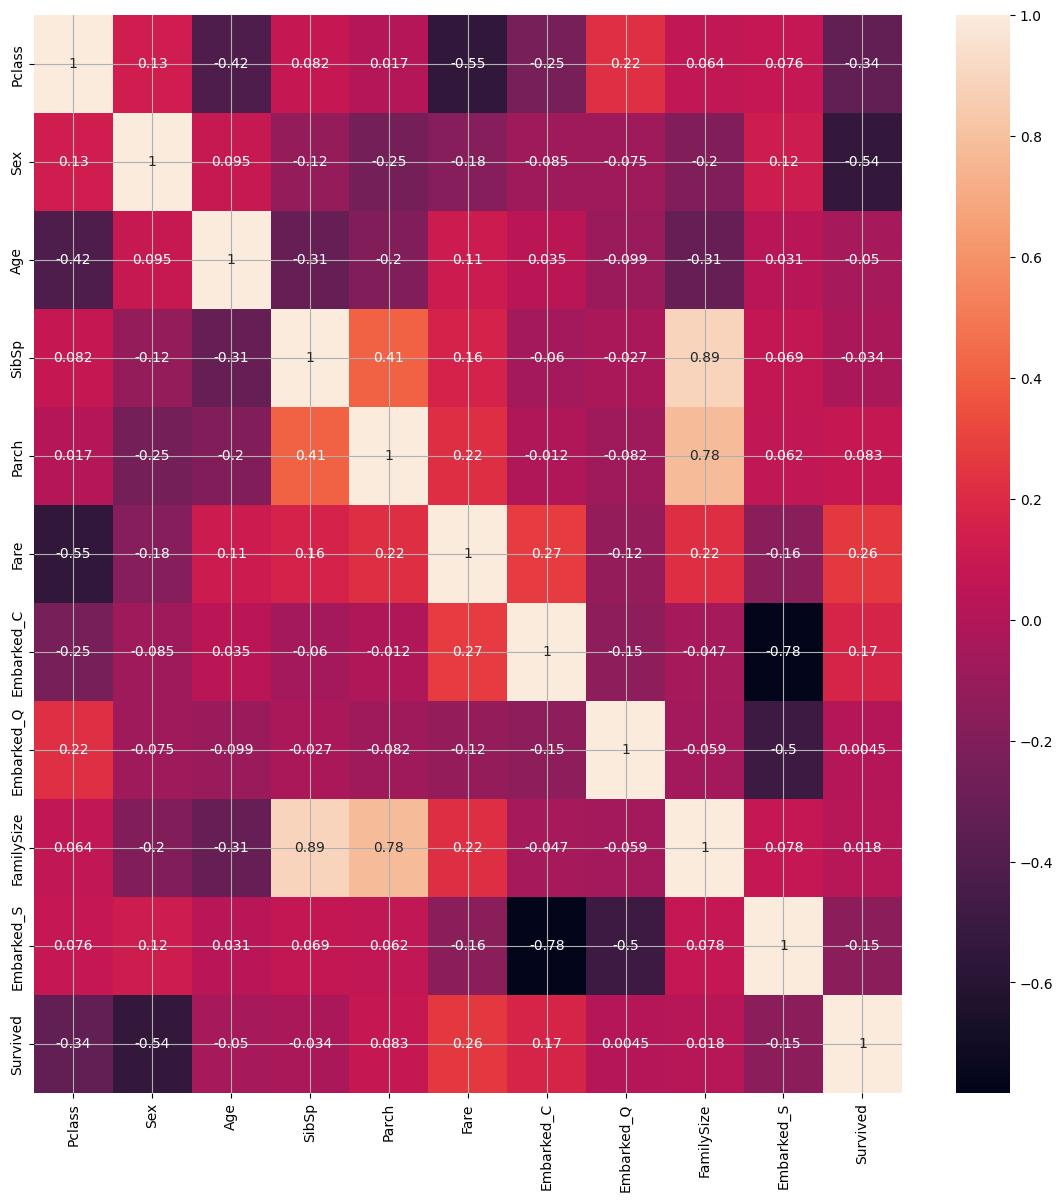

In [41]:
plt.figure(figsize=(14, 14))
sns.heatmap(dfe.corr(), annot=True);

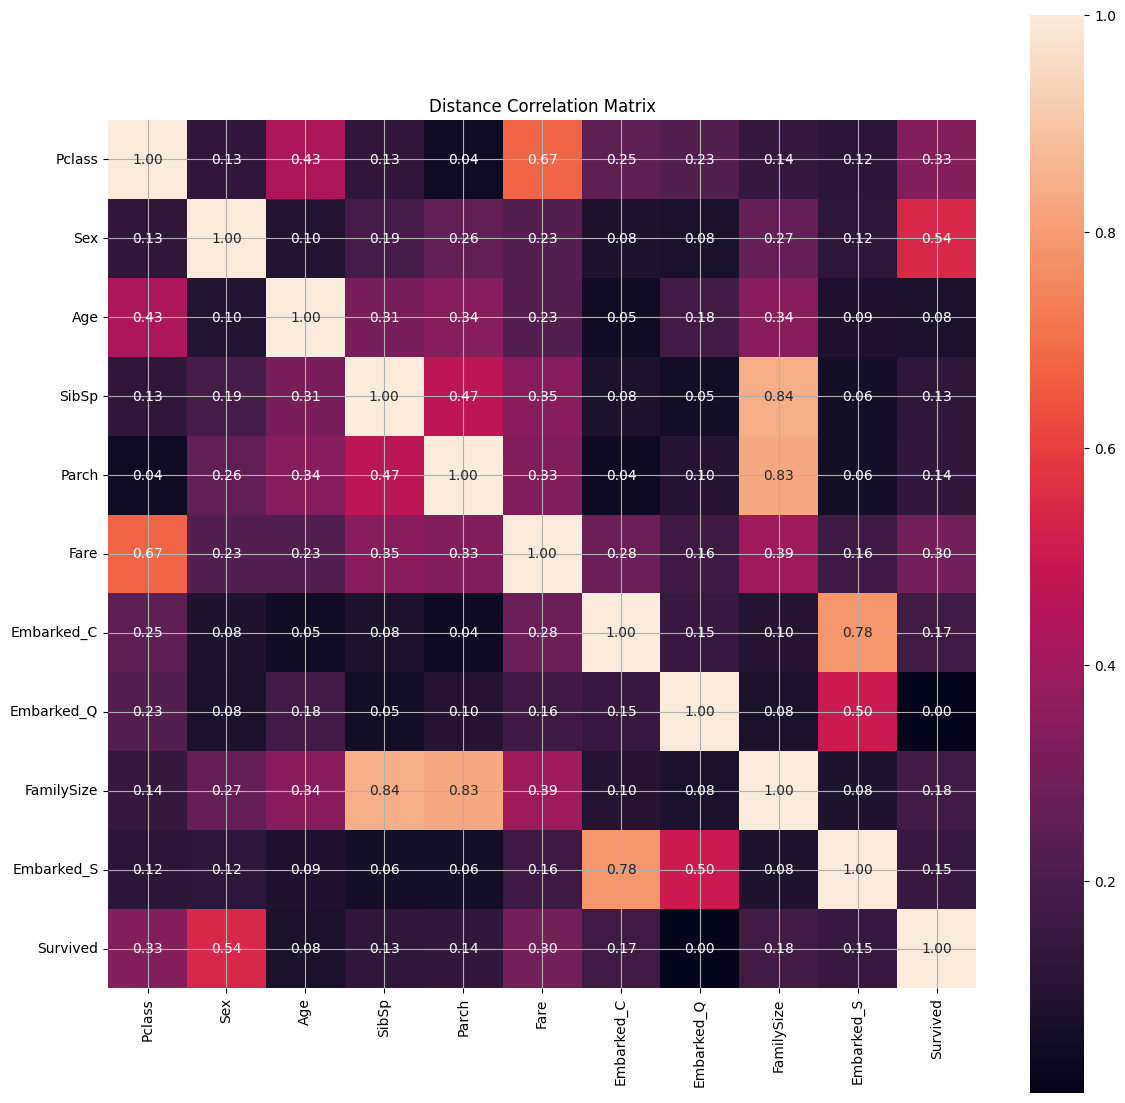

In [42]:
import dcor

cols = dfe.columns

dcorr_matrix = pd.DataFrame(
    index=cols,
    columns=cols,
    dtype=float
)

for col1 in cols:
    for col2 in cols:
        dcorr_matrix.loc[col1, col2] = dcor.distance_correlation(
            dfe[col1],
            dfe[col2]
        )

plt.figure(figsize=(14, 14))
sns.heatmap(dcorr_matrix,
            annot=True,
            fmt=".2f",
            square=True)

plt.title("Distance Correlation Matrix")
plt.show()

In [ ]:
target = 'Survived'

for col in dfe.columns:
    if col != target:
        dcorr = dcor.distance_correlation( 
            dfe[col],
            dfe[target]
        )
        print(f'{col:12s}: {dcorr:.4f}')

Pclass      : 0.3328
Sex         : 0.5416
Age         : 0.0764
SibSp       : 0.1284
Parch       : 0.1361
Fare        : 0.2984
Embarked_C  : 0.1700
Embarked_Q  : 0.0045
FamilySize  : 0.1754
Embarked_S  : 0.1518


In [44]:
from scipy.stats import (
    chi2_contingency,
    pointbiserialr,
    f_oneway,
    spearmanr,
    pearsonr
)

from sklearn.metrics import mutual_info_score
import dcor


# ==========================================================
# Helpers
# ==========================================================

def is_binary(x):
    return x.dropna().nunique() == 2


def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1) + 1e-12)))


def permutation_pvalue(score, perm_scores):
    return (np.sum(perm_scores >= score) + 1) / (len(perm_scores) + 1)


# ==========================================================
# Numeric - Numeric
# ==========================================================

def numeric_numeric_test(x, y, n_perm=300):

    x = x.values
    y = y.values

    # Spearman (robust default)
    score, _ = spearmanr(x, y, nan_policy="omit")

    perm_scores = np.zeros(n_perm)

    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        perm_scores[i], _ = spearmanr(x, y_perm, nan_policy="omit")

    pvalue = permutation_pvalue(score, perm_scores)

    return score, pvalue, "Spearman"


# ==========================================================
# Numeric - Binary
# ==========================================================

def numeric_binary_test(x, y):

    # y must be binary encoded
    y_encoded = pd.factorize(y)[0]

    score, pvalue = pointbiserialr(x, y_encoded)

    return abs(score), pvalue, "PointBiserial"


# ==========================================================
# Numeric - Categorical (multi-class)
# ==========================================================

def numeric_categorical_test(x, y, n_perm=300):

    groups = [x[y == c] for c in np.unique(y)]

    # ANOVA F-test
    f_stat, pvalue = f_oneway(*groups)

    # Effect size (eta squared)
    grand_mean = x.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = sum((x - grand_mean) ** 2)

    eta_sq = ss_between / (ss_total + 1e-12)

    return eta_sq, pvalue, "ANOVA_eta2"


# ==========================================================
# Categorical - Categorical
# ==========================================================

def categorical_categorical_test(x, y):

    ct = pd.crosstab(x, y)

    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(ct)

    return v, p, "Chi2_CramersV"


# ==========================================================
# Numeric - Numeric (nonlinear)
# ==========================================================

def distance_corr_test(x, y, n_perm=300):

    x = np.asarray(x)
    y = np.asarray(y)

    score = dcor.distance_correlation(x, y)

    perm_scores = np.zeros(n_perm)

    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        perm_scores[i] = dcor.distance_correlation(x, y_perm)

    pvalue = permutation_pvalue(score, perm_scores)

    return score, pvalue, "DistanceCorr"


# ==========================================================
# MAIN ENGINE
# ==========================================================

def association_table(df, numeric_cols, categorical_cols, n_perm=300):

    results = []

    cols = numeric_cols + categorical_cols

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):

            c1, c2 = cols[i], cols[j]

            d = df[[c1, c2]].dropna()
            if len(d) < 10:
                continue

            x = d[c1]
            y = d[c2]

            try:

                # -----------------------------
                # Numeric - Numeric
                # -----------------------------
                if c1 in numeric_cols and c2 in numeric_cols:

                    # linear + nonlinear hybrid
                    score, p, method = numeric_numeric_test(x, y, n_perm)

                    # also compute nonlinear check
                    dscore, dp, _ = distance_corr_test(x, y, n_perm)

                    results.append({
                        "col1": c1,
                        "col2": c2,
                        "type": "numeric-numeric",
                        "method": f"{method} + DistanceCorr",
                        "score": score,
                        "distance_corr": dscore,
                        "pvalue": min(p, dp)
                    })

                # -----------------------------
                # Categorical - Categorical
                # -----------------------------
                elif c1 in categorical_cols and c2 in categorical_cols:

                    score, p, method = categorical_categorical_test(x, y)

                    results.append({
                        "col1": c1,
                        "col2": c2,
                        "type": "categorical-categorical",
                        "method": method,
                        "score": score,
                        "pvalue": p
                    })

                # -----------------------------
                # Numeric - Categorical
                # -----------------------------
                else:

                    # detect orientation
                    if c1 in numeric_cols:
                        x_num, y_cat = x, y
                    else:
                        x_num, y_cat = y, x

                    # binary case
                    if is_binary(y_cat):

                        score, p, method = numeric_binary_test(x_num, y_cat)

                    # multi-class case
                    else:

                        score, p, method = numeric_categorical_test(x_num, y_cat, n_perm)

                    results.append({
                        "col1": c1,
                        "col2": c2,
                        "type": "numeric-categorical",
                        "method": method,
                        "score": score,
                        "pvalue": p
                    })

            except Exception:
                continue

    return (
        pd.DataFrame(results)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

In [45]:
numeric_cols = [
    "Age",
    "Fare",
    "FamilySize"
]

categorical_cols = [
    "Sex",
    "Pclass",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

assoc = association_table(
    dfe,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    n_perm=500
)

assoc

assoc 

,col1,col2,type,method,score,distance_corr,pvalue
0,Embarked_C,Embarked_S,categorical-categorical,Chi2_CramersV,0.779397,NaN,1.855344e-119
1,Fare,FamilySize,numeric-numeric,Spearman + DistanceCorr,0.533177,0.394539,1.996008e-03
2,Embarked_Q,Embarked_S,categorical-categorical,Chi2_CramersV,0.494785,NaN,2.961789e-49
3,Fare,Pclass,numeric-categorical,ANOVA_eta2,0.351759,NaN,3.973125e-84
4,Pclass,Embarked_C,categorical-categorical,Chi2_CramersV,0.302355,NaN,2.249862e-18
5,Fare,Embarked_C,numeric-categorical,PointBiserial,0.270731,NaN,2.127251e-16
6,Pclass,Embarked_Q,categorical-categorical,Chi2_CramersV,0.237178,NaN,1.382225e-11
7,Pclass,Embarked_S,categorical-categorical,Chi2_CramersV,0.222793,NaN,2.617806e-10
8,FamilySize,Sex,numeric-categorical,PointBiserial,0.203191,NaN,9.732248e-10
9,Fare,Sex,numeric-categorical,PointBiserial,0.179958,NaN,6.581200e-08


In [46]:
from scipy.stats import (
    chi2_contingency,
    pointbiserialr,
    spearmanr,
    f_oneway
)

from sklearn.metrics import mutual_info_score
import dcor


# ==========================================================
# Helpers
# ==========================================================

def is_binary(series):
    return series.dropna().nunique() == 2


def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1) + 1e-12)))


# ==========================================================
# Numeric vs Binary target
# ==========================================================

def numeric_binary(x, y):
    y_enc = pd.factorize(y)[0]
    r, p = pointbiserialr(x, y_enc)
    return abs(r), p, "PointBiserial"


# ==========================================================
# Numeric vs Categorical target (multi-class general case)
# ==========================================================

def numeric_categorical(x, y):

    groups = [x[y == c] for c in np.unique(y)]

    f, p = f_oneway(*groups)

    # effect size (eta squared)
    grand_mean = x.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((x - grand_mean) ** 2).sum()

    eta2 = ss_between / (ss_total + 1e-12)

    return eta2, p, "ANOVA_eta2"


# ==========================================================
# Categorical vs Categorical target
# ==========================================================

def categorical_categorical(x, y):

    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)

    v = cramers_v(ct)

    return v, p, "Chi2_CramersV"


# ==========================================================
# Numeric vs target (nonlinear check)
# ==========================================================

def distance_corr(x, y, n_perm=200):

    x = np.asarray(x)
    y = np.asarray(y)

    real = dcor.distance_correlation(x, y)

    perm = np.zeros(n_perm)

    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        perm[i] = dcor.distance_correlation(x, y_perm)

    p = (np.sum(perm >= real) + 1) / (n_perm + 1)

    return real, p, "DistanceCorr"


# ==========================================================
# MAIN FUNCTION (Survived-centric)
# ==========================================================

def survived_association_table(
    df,
    target="Survived",
    numeric_cols=None,
    categorical_cols=None,
    n_perm=200
):

    results = []

    y = df[target]

    for col in df.columns:

        if col == target:
            continue

        d = df[[col, target]].dropna()

        if len(d) < 10:
            continue

        x = d[col]
        y = d[target]

        try:

            # -----------------------------------------
            # Numeric feature
            # -----------------------------------------
            if col in numeric_cols:

                if is_binary(y):

                    r, p, method = numeric_binary(x, y)

                    # optional nonlinear check
                    dcor_score, dcor_p, _ = distance_corr(x, y, n_perm)

                    results.append({
                        "feature": col,
                        "target": target,
                        "type": "numeric → binary",
                        "method": f"{method} + DistanceCorr",
                        "score": r,
                        "distance_corr": dcor_score,
                        "pvalue": min(p, dcor_p)
                    })

                else:

                    score, p, method = numeric_categorical(x, y)

                    results.append({
                        "feature": col,
                        "target": target,
                        "type": "numeric → categorical",
                        "method": method,
                        "score": score,
                        "pvalue": p
                    })

            # -----------------------------------------
            # Categorical feature
            # -----------------------------------------
            else:

                ct = pd.crosstab(x, y)
                score, p, method = categorical_categorical(x, y)

                results.append({
                    "feature": col,
                    "target": target,
                    "type": "categorical → target",
                    "method": method,
                    "score": score,
                    "pvalue": p
                })

        except Exception:
            continue

    return (
        pd.DataFrame(results)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

In [ ]:
target = "Survived"

numeric_cols = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

categorical_cols = [
    "Sex",
    "Pclass",
    "Embarked"
]

result = survived_association_table(
    df=df,
    target="Survived",
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols, 
    n_perm=200
)
result

,feature,target,type,method,score,pvalue,distance_corr
0,Sex,Survived,categorical → target,Chi2_CramersV,0.539160,3.779910e-58,NaN
1,Pclass,Survived,categorical → target,Chi2_CramersV,0.337029,1.181362e-22,NaN
2,FamilySize,Survived,categorical → target,Chi2_CramersV,0.303121,2.239008e-14,NaN
3,Fare,Survived,numeric → binary,PointBiserial + DistanceCorr,0.255290,1.079789e-14,0.298424
4,Embarked,Survived,categorical → target,Chi2_CramersV,0.172617,1.769922e-06,NaN
5,Parch,Survived,numeric → binary,PointBiserial + DistanceCorr,0.083151,4.975124e-03,0.136084
6,Age,Survived,numeric → binary,PointBiserial + DistanceCorr,0.050053,3.482587e-02,0.076387
7,SibSp,Survived,numeric → binary,PointBiserial + DistanceCorr,0.034040,4.975124e-03,0.128369


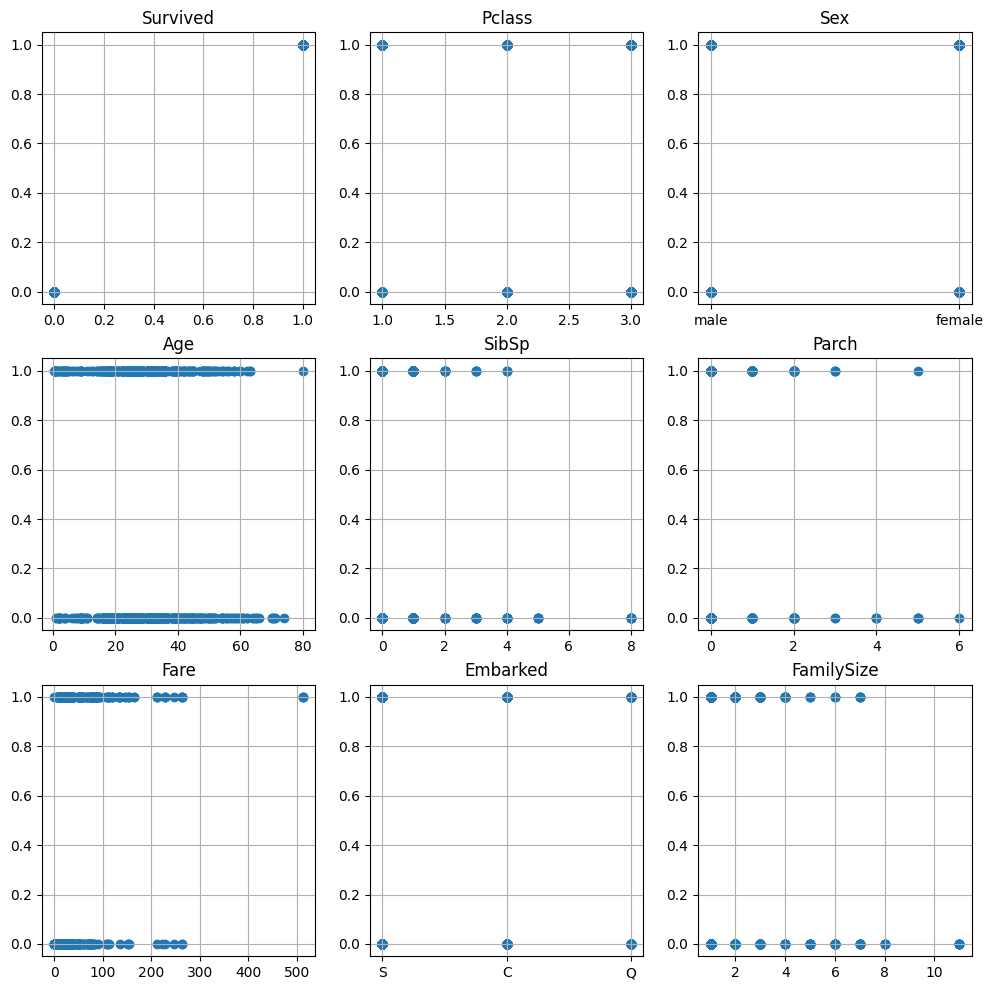

In [48]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes_flat = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes_flat[i]
    ax.scatter(df[col], df.Survived)
    ax.set_title(col) 

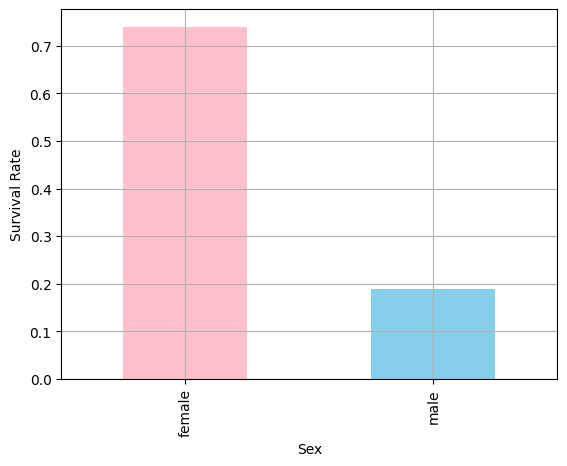

In [49]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['pink', 'skyblue'])
plt.ylabel('Survival Rate') 
plt.show()

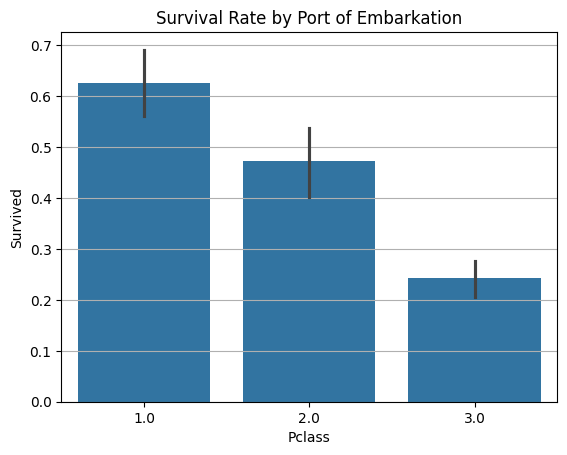

In [50]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Port of Embarkation')
plt.show()

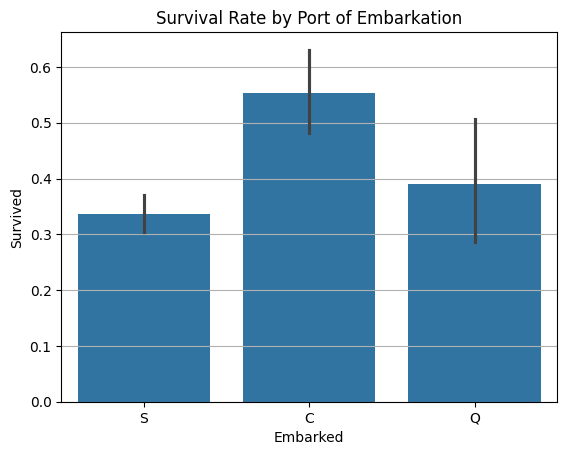

In [51]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Port of Embarkation')
plt.show()

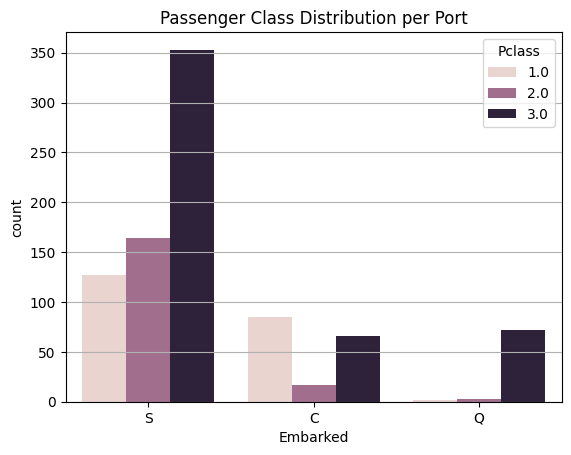

In [52]:
sns.countplot(x='Embarked', hue='Pclass', data=df)
plt.title('Passenger Class Distribution per Port')
plt.show()

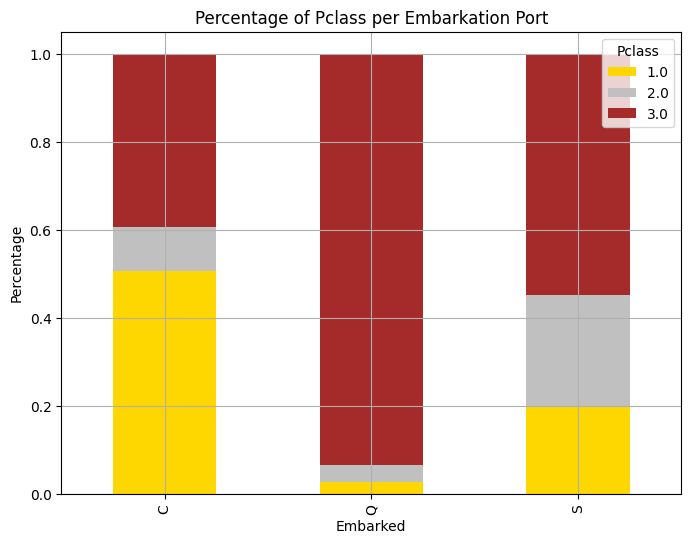

In [53]:
crosstab = pd.crosstab(df['Embarked'], df['Pclass'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), color=['gold', 'silver', 'brown'])

plt.title('Percentage of Pclass per Embarkation Port')
plt.ylabel('Percentage')
plt.show()


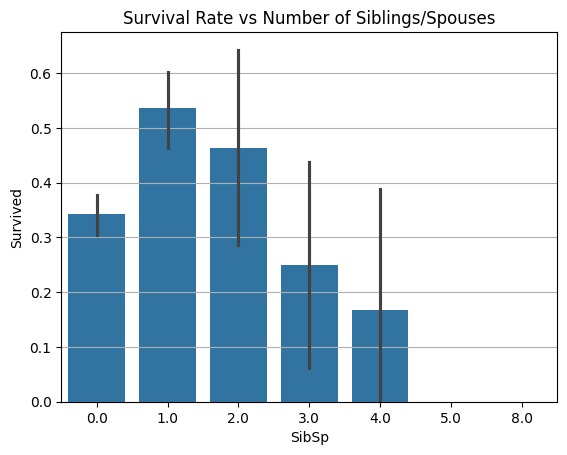

In [54]:
sns.barplot(x='SibSp', y='Survived', data=df)
plt.title('Survival Rate vs Number of Siblings/Spouses')
plt.show()

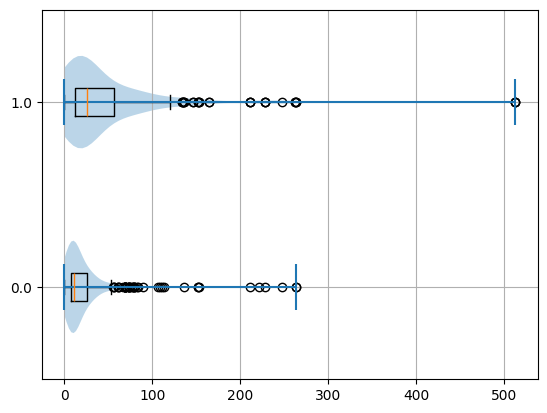

In [55]:
col = 'Survived'
plt.boxplot([df.Fare[df[col] == var] for var in df[col].unique()], labels=df[col].unique(), vert=False);
plt.violinplot([df.Fare[df[col] == var] for var in df[col].unique()], vert=False);

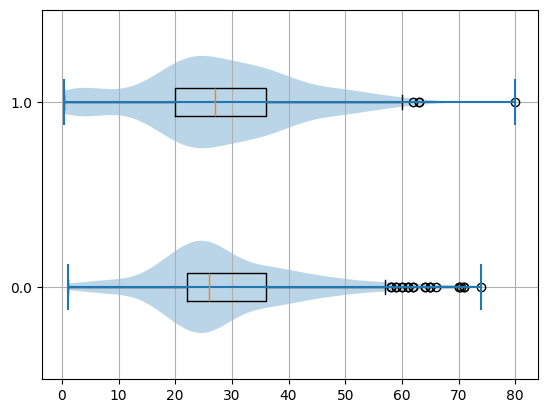

In [56]:
col = 'Survived'
plt.boxplot([df.Age[df[col] == var] for var in df[col].unique()], labels=df[col].unique(), vert=False);
plt.violinplot([df.Age[df[col] == var] for var in df[col].unique()], vert=False);

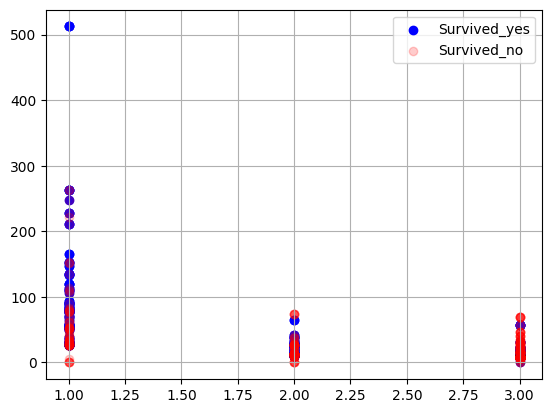

In [57]:
flags = df.Survived == 1
plt.scatter(df.Pclass[flags], df.Fare[flags], c='b', label='Survived_yes',alpha=1)
plt.scatter(df.Pclass[~flags], df.Fare[~flags], c='r', label='Survived_no',alpha=0.2)  
plt.legend();

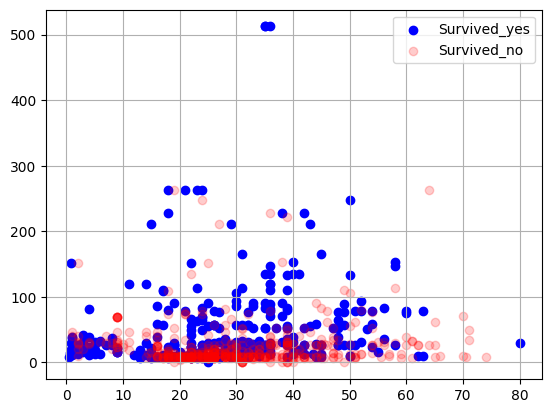

In [58]:
flags = df.Survived == 1
plt.scatter(df.Age[flags], df.Fare[flags], c='b', label='Survived_yes',alpha=1)
plt.scatter(df.Age[~flags], df.Fare[~flags], c='r', label='Survived_no',alpha=0.2)  
plt.legend();

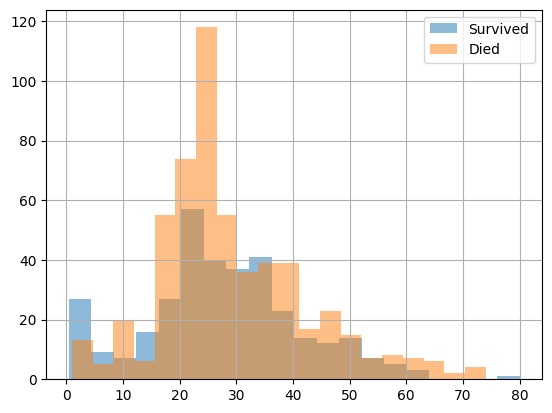

In [59]:
plt.hist(df[df.Survived == 1]['Age'], bins=20, alpha=0.5, label='Survived')
plt.hist(df[df.Survived == 0]['Age'], bins=20, alpha=0.5, label='Died')
plt.legend()
plt.show()


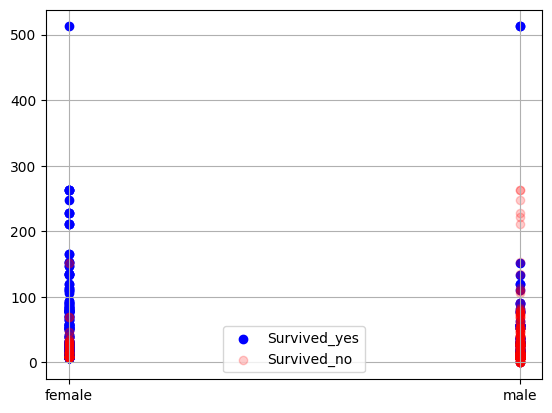

In [60]:
flags = df.Survived == 1
plt.scatter(df.Sex[flags], df.Fare[flags], c='b', label='Survived_yes',alpha=1)
plt.scatter(df.Sex[~flags], df.Fare[~flags], c='r', label='Survived_no',alpha=0.2)  
plt.legend();

outlier

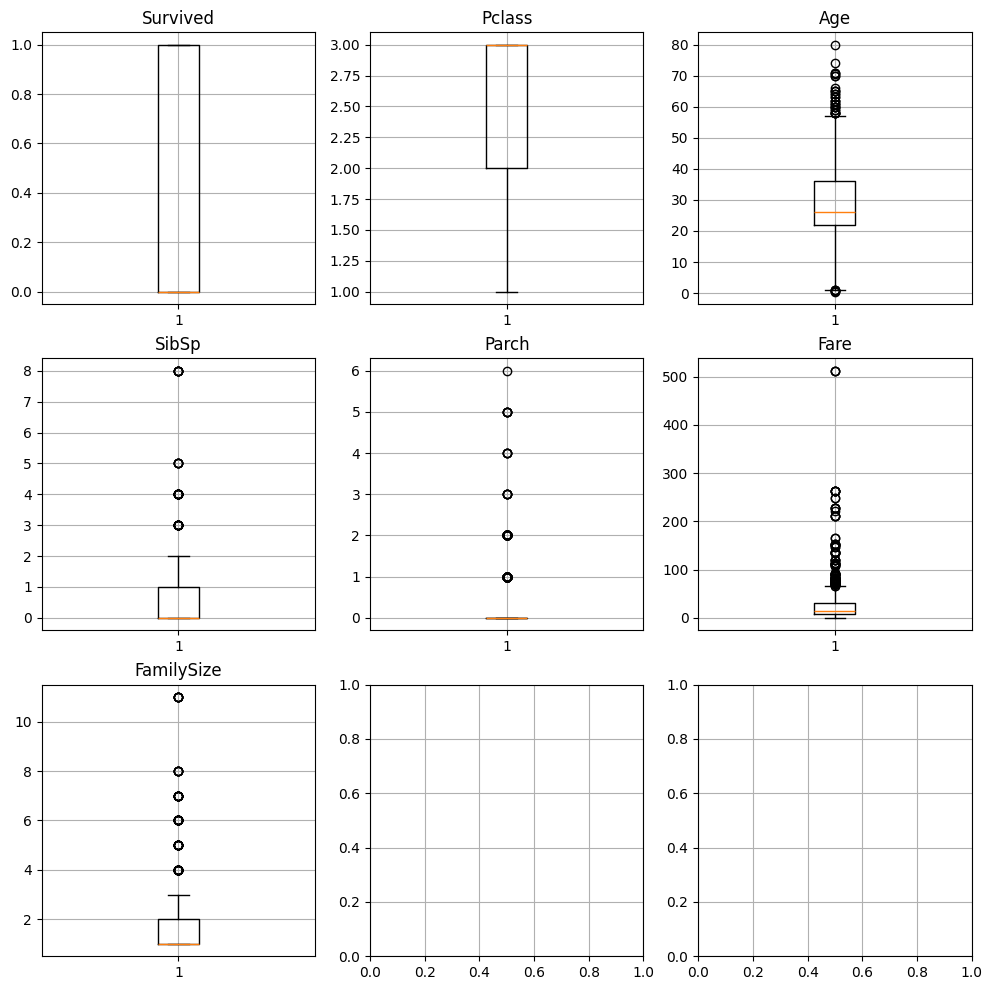

In [61]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes_flat = axes.flatten()

for i, col in enumerate(df.select_dtypes('float64')):
        ax = axes_flat[i]
        ax.boxplot(df[col]) 
        ax.set_title(col) 

scale

In [62]:
scaler = RobustScaler()
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
dfe[num_cols] = scaler.fit_transform(df[num_cols]) 
dfe 

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,FamilySize,Embarked_S,Survived
0,3.0,1.0,-0.285714,1.0,0.0,-0.311813,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.857143,1.0,0.0,2.459687,1.0,0.0,1.0,0.0,1.0
2,3.0,0.0,0.000000,0.0,0.0,-0.282598,0.0,0.0,0.0,1.0,1.0
3,1.0,0.0,0.642857,1.0,0.0,1.672674,0.0,0.0,1.0,1.0,1.0
4,3.0,1.0,0.642857,0.0,0.0,-0.277188,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
884,2.0,1.0,0.071429,0.0,0.0,-0.062941,0.0,0.0,0.0,1.0,0.0
885,1.0,0.0,-0.500000,0.0,0.0,0.672856,0.0,0.0,0.0,1.0,1.0
886,3.0,0.0,-1.214286,1.0,2.0,0.389358,0.0,0.0,3.0,1.0,0.0
887,1.0,1.0,0.000000,0.0,0.0,0.672856,1.0,0.0,0.0,0.0,1.0


In [63]:
from sklearn.feature_selection import mutual_info_classif

X = dfe.drop(columns=["Survived"])
y = dfe["Survived"]

mi = mutual_info_classif(X, y)

mi_scores = (
    pd.Series(mi, index=X.columns)
      .sort_values(ascending=False)
)

print(mi_scores)   

Sex           0.154115
Fare          0.138358
Pclass        0.067419
FamilySize    0.038910
Embarked_S    0.031537
Parch         0.029851
SibSp         0.027410
Age           0.018640
Embarked_C    0.014900
Embarked_Q    0.000000
dtype: float64
